In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Current notebook location
# ------------------------------------------------------------

CURRENT_DIR = Path.cwd()

print("Current directory:")
print(CURRENT_DIR)

Current directory:
c:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\bluestock_mf_capstone\notebooks


In [3]:
BASE_DIR = None

for path in [CURRENT_DIR] + list(CURRENT_DIR.parents):

    if (
        (path / "data").exists()
        and (path / "scripts").exists()
    ):
        BASE_DIR = path
        break

if BASE_DIR is None:
    raise FileNotFoundError(
        "Project root not found. "
        "Make sure the notebook is inside the project folder."
    )


In [4]:
DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = BASE_DIR / "reports"
SCRIPTS_DIR = BASE_DIR / "scripts"

# Create reports folder if needed
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
print("\n" + "=" * 60)
print("PROJECT PATHS")
print("=" * 60)

print("BASE DIR      :", BASE_DIR)
print("DATA DIR      :", DATA_DIR)
print("RAW DIR       :", RAW_DIR)
print("PROCESSED DIR :", PROCESSED_DIR)
print("REPORTS DIR   :", REPORTS_DIR)
print("SCRIPTS DIR   :", SCRIPTS_DIR)


PROJECT PATHS
BASE DIR      : c:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\bluestock_mf_capstone
DATA DIR      : c:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\bluestock_mf_capstone\data
RAW DIR       : c:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\bluestock_mf_capstone\data\raw
PROCESSED DIR : c:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\bluestock_mf_capstone\data\processed
REPORTS DIR   : c:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\bluestock_mf_capstone\reports
SCRIPTS DIR   : c:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\bluestock_mf_capstone\scripts


In [6]:
# ============================================================
# CELL 2 - FIND ALL CSV FILES
# ============================================================

csv_files = list(DATA_DIR.rglob("*.csv"))

print("=" * 60)
print("AVAILABLE CSV FILES")
print("=" * 60)

if not csv_files:
    print("No CSV files found.")
else:
    for i, file in enumerate(sorted(csv_files), start=1):
        print(f"{i}. {file.relative_to(BASE_DIR)}")

print("\nTotal CSV files:", len(csv_files))


AVAILABLE CSV FILES
1. data\processed\01_fund_master.csv
2. data\processed\02_nav_history.csv
3. data\processed\03_aum_by_fund_house.csv
4. data\processed\04_monthly_sip_inflows.csv
5. data\processed\05_category_inflows.csv
6. data\processed\06_industry_folio_count.csv
7. data\processed\07_scheme_performance.csv
8. data\processed\08_investor_transactions.csv
9. data\processed\09_portfolio_holdings.csv
10. data\processed\10_benchmark_indices.csv
11. data\processed\Aditya Birla Sun Life Banking & PSU Debt Fund  - DIRECT - IDCW.csv
12. data\processed\Aditya Birla Sun Life Mutual Fund.csv
13. data\processed\alpha_beta.csv
14. data\processed\Axis ELSS Tax Saver Fund - Direct Plan - Growth Option.csv
15. data\processed\Axis Mutual Fund.csv
16. data\processed\Axis_Bluechip.csv
17. data\processed\cagr_comparison.csv
18. data\processed\fund_master.csv
19. data\processed\fund_master_clean.csv
20. data\processed\fund_scorecard.csv
21. data\processed\HDFC Money Market Fund - Growth Option - Direct

In [7]:
# ============================================================
# CELL 3 - IDENTIFY NAV DATASET
# ============================================================

nav_candidates = [
    file for file in csv_files
    if "nav" in file.name.lower()
]

print("=" * 60)
print("NAV-RELATED CSV FILES")
print("=" * 60)

for i, file in enumerate(nav_candidates, start=1):
    print(f"{i}. {file.relative_to(BASE_DIR)}")

if not nav_candidates:
    raise FileNotFoundError(
        "No CSV file containing 'nav' in its filename was found."
    )

NAV-RELATED CSV FILES
1. data\processed\02_nav_history.csv
2. data\processed\HDFC_TOP100_NAV.csv
3. data\processed\live_nav_fetched.csv
4. data\processed\nav_history.csv
5. data\processed\nav_history_clean.csv
6. data\raw\02_nav_history.csv
7. data\raw\HDFC_TOP100_NAV.csv
8. data\raw\live_nav_fetched.csv
9. data\raw\nav_history.csv


In [8]:
# ============================================================
# CELL 4 - LOAD NAV DATA
# ============================================================

NAV_FILE = nav_candidates[0]

print("Loading NAV file:")
print(NAV_FILE)

nav = pd.read_csv(NAV_FILE)

print("\nNAV dataset loaded successfully!")
print("Shape:", nav.shape)

print("\nColumns:")
print(nav.columns.tolist())

print("\nFirst 5 rows:")
display(nav.head())

Loading NAV file:
c:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\bluestock_mf_capstone\data\processed\02_nav_history.csv

NAV dataset loaded successfully!
Shape: (46000, 3)

Columns:
['amfi_code', 'date', 'nav']

First 5 rows:


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [9]:
# ============================================================
# CELL 5 - NAV DATA INSPECTION
# ============================================================

print("=" * 60)
print("NAV DATA INFORMATION")
print("=" * 60)

print("\nShape:")
print(nav.shape)

print("\nData types:")
print(nav.dtypes)

print("\nMissing values:")
print(nav.isna().sum())

print("\nSample:")
display(nav.head(10))

NAV DATA INFORMATION

Shape:
(46000, 3)

Data types:
amfi_code      int64
date          object
nav          float64
dtype: object

Missing values:
amfi_code    0
date         0
nav          0
dtype: int64

Sample:


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692
5,119551,2022-01-10,55.2835
6,119551,2022-01-11,56.0878
7,119551,2022-01-12,56.4978
8,119551,2022-01-13,56.2934
9,119551,2022-01-14,56.5926


In [13]:
# ============================================================
# CELL 6 - STANDARDIZE NAV COLUMNS
# ============================================================

# Your actual columns:
# amfi_code | date | nav

nav.columns = (
    nav.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Rename only the columns we need
nav = nav.rename(columns={
    "amfi_code": "amfi_code",
    "date": "date",
    "nav": "nav"
})

print("Working columns:")
print(nav.columns.tolist())

print("\nFirst 5 rows:")
display(nav.head())

Working columns:
['amfi_code', 'date', 'nav']

First 5 rows:


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [14]:
# ============================================================
# CELL 7 - CLEAN NAV DATA
# ============================================================

# Convert date
nav["date"] = pd.to_datetime(
    nav["date"],
    errors="coerce"
)

# Convert NAV to numeric
nav["nav"] = pd.to_numeric(
    nav["nav"],
    errors="coerce"
)

# Convert AMFI code to string
nav["amfi_code"] = nav["amfi_code"].astype(str).str.strip()

# Remove invalid records
nav = nav.dropna(
    subset=["amfi_code", "date", "nav"]
).copy()

# NAV must be positive
nav = nav[nav["nav"] > 0].copy()

# Sort
nav = nav.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

print("Clean NAV shape:", nav.shape)

print("Number of schemes:",
      nav["amfi_code"].nunique())

print(
    "Date range:",
    nav["date"].min(),
    "to",
    nav["date"].max()
)

print("\nMissing values:")
print(
    nav[
        ["amfi_code", "date", "nav"]
    ].isna().sum()
)

display(nav.head())

Clean NAV shape: (46000, 3)
Number of schemes: 40
Date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00

Missing values:
amfi_code    0
date         0
nav          0
dtype: int64


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [16]:
# ============================================================
# STEP 8 - DUPLICATE CHECK
# ============================================================

duplicates = nav.duplicated(
    subset=["amfi_code", "date"]
).sum()

print("Duplicate AMFI-code/date records:", duplicates)

if duplicates > 0:
    nav = (
        nav
        .drop_duplicates(
            subset=["amfi_code", "date"],
            keep="last"
        )
        .reset_index(drop=True)
    )

print("Shape after duplicate removal:", nav.shape)

remaining_duplicates = nav.duplicated(
    subset=["amfi_code", "date"]
).sum()

print("Remaining duplicates:", remaining_duplicates)

Duplicate AMFI-code/date records: 0
Shape after duplicate removal: (46000, 3)
Remaining duplicates: 0


In [17]:
# ============================================================
# STEP 9 - DAILY RETURNS
# ============================================================

nav["daily_return"] = (
    nav
    .groupby("amfi_code")["nav"]
    .pct_change()
)

returns_df = nav.dropna(
    subset=["daily_return"]
).copy()

print("Return observations:", len(returns_df))

print(
    "Schemes with returns:",
    returns_df["amfi_code"].nunique()
)

display(
    returns_df[
        ["amfi_code", "date", "nav", "daily_return"]
    ].head(10)
)

Return observations: 45960
Schemes with returns: 40


,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073
10,100016,2022-01-17,514.7627,0.000776


In [18]:
# ============================================================
# STEP 10 - RETURN VALIDATION
# ============================================================

print("=" * 60)
print("DAILY RETURN VALIDATION")
print("=" * 60)

print("\nReturn statistics:")
display(
    returns_df["daily_return"].describe()
)

print("\nMissing returns:")
print(
    returns_df["daily_return"].isna().sum()
)

print("\nInfinite returns:")
print(
    np.isinf(
        returns_df["daily_return"]
    ).sum()
)

print("\nLowest 10 returns:")
display(
    returns_df[
        ["amfi_code", "date", "daily_return"]
    ]
    .sort_values("daily_return")
    .head(10)
)

print("\nHighest 10 returns:")
display(
    returns_df[
        ["amfi_code", "date", "daily_return"]
    ]
    .sort_values(
        "daily_return",
        ascending=False
    )
    .head(10)
)

DAILY RETURN VALIDATION

Return statistics:


count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


Missing returns:
0

Infinite returns:
0

Lowest 10 returns:


,amfi_code,date,daily_return
12774,118634,2022-06-24,-0.058102
4917,101207,2023-03-22,-0.051847
12952,118634,2023-03-01,-0.050335
45312,149324,2023-10-11,-0.048870
5560,101207,2025-09-08,-0.048634
19804,119095,2022-12-23,-0.048367
13333,118634,2024-08-15,-0.048305
20307,119095,2024-11-27,-0.046524
26048,119599,2024-11-14,-0.045429
38520,125498,2024-03-11,-0.045218



Highest 10 returns:


,amfi_code,date,daily_return
24745,119598,2024-04-15,0.064713
13226,118634,2024-03-19,0.059304
5207,101207,2024-05-01,0.054851
25566,119599,2023-01-10,0.053320
25832,119599,2024-01-17,0.051811
24155,119598,2022-01-10,0.051113
24371,119598,2022-11-08,0.049051
45082,149324,2022-11-23,0.048490
24356,119598,2022-10-18,0.048454
25091,119598,2025-08-12,0.047123


In [22]:
# ============================================================
# STEP 12 / 13 - VaR / CVaR VALIDATION + HIGHEST RISK
# ============================================================

print("=" * 60)
print("VaR / CVaR VALIDATION")
print("=" * 60)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

print(
    "Number of schemes:",
    var_cvar_df["amfi_code"].nunique()
)

print(
    "Missing VaR:",
    var_cvar_df["VaR_95"].isna().sum()
)

print(
    "Missing CVaR:",
    var_cvar_df["CVaR_95"].isna().sum()
)

print(
    "CVaR <= VaR:",
    (
        var_cvar_df["CVaR_95"]
        <= var_cvar_df["VaR_95"]
    ).all()
)

# ------------------------------------------------------------
# Most negative VaR
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("10 SCHEMES WITH MOST NEGATIVE VaR")
print("=" * 60)

highest_var_risk = (
    var_cvar_df
    .sort_values("VaR_95", ascending=True)
    [
        [
            "amfi_code",
            "observations",
            "VaR_95",
            "CVaR_95",
            "VaR_95_pct",
            "CVaR_95_pct"
        ]
    ]
    .head(10)
)

display(highest_var_risk)

# ------------------------------------------------------------
# Most negative CVaR
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("10 SCHEMES WITH MOST NEGATIVE CVaR")
print("=" * 60)

highest_cvar_risk = (
    var_cvar_df
    .sort_values("CVaR_95", ascending=True)
    [
        [
            "amfi_code",
            "observations",
            "VaR_95",
            "CVaR_95",
            "VaR_95_pct",
            "CVaR_95_pct"
        ]
    ]
    .head(10)
)

display(highest_cvar_risk)

VaR / CVaR VALIDATION
Number of schemes: 40
Missing VaR: 0
Missing CVaR: 0
CVaR <= VaR: True

10 SCHEMES WITH MOST NEGATIVE VaR


,amfi_code,observations,VaR_95,CVaR_95,VaR_95_pct,CVaR_95_pct
0,119599,1149,-0.026859,-0.032384,-2.685944,-3.238412
1,119095,1149,-0.026188,-0.031667,-2.618842,-3.166729
2,101207,1149,-0.026021,-0.032459,-2.602125,-3.245906
3,118634,1149,-0.025438,-0.032304,-2.543811,-3.230407
4,119598,1149,-0.024507,-0.030595,-2.450705,-3.059526
5,149324,1149,-0.023483,-0.031036,-2.348307,-3.103625
6,102886,1149,-0.019220,-0.023251,-1.922028,-2.325086
7,100033,1149,-0.019034,-0.023456,-1.903354,-2.345576
8,120505,1149,-0.018892,-0.024342,-1.889179,-2.434207
9,119094,1149,-0.018480,-0.024260,-1.848028,-2.426006



10 SCHEMES WITH MOST NEGATIVE CVaR


,amfi_code,observations,VaR_95,CVaR_95,VaR_95_pct,CVaR_95_pct
2,101207,1149,-0.026021,-0.032459,-2.602125,-3.245906
0,119599,1149,-0.026859,-0.032384,-2.685944,-3.238412
3,118634,1149,-0.025438,-0.032304,-2.543811,-3.230407
1,119095,1149,-0.026188,-0.031667,-2.618842,-3.166729
5,149324,1149,-0.023483,-0.031036,-2.348307,-3.103625
4,119598,1149,-0.024507,-0.030595,-2.450705,-3.059526
8,120505,1149,-0.018892,-0.024342,-1.889179,-2.434207
9,119094,1149,-0.018480,-0.024260,-1.848028,-2.426006
7,100033,1149,-0.019034,-0.023456,-1.903354,-2.345576
6,102886,1149,-0.019220,-0.023251,-1.922028,-2.325086


In [ ]:
# ============================================================
# STEP 12 / 13 - VaR / CVaR VALIDATION + HIGHEST RISK
# ============================================================

print("=" * 60)
print("VaR / CVaR VALIDATION")
print("=" * 60)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

print(
    "Number of schemes:",
    var_cvar_df["amfi_code"].nunique()
)

print(
    "Missing VaR:",
    var_cvar_df["VaR_95"].isna().sum()
)

print(
    "Missing CVaR:",
    var_cvar_df["CVaR_95"].isna().sum()
)

print(
    "CVaR <= VaR:",
    (
        var_cvar_df["CVaR_95"]
        <= var_cvar_df["VaR_95"]
    ).all()
)

# ------------------------------------------------------------
# Most negative VaR
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("10 SCHEMES WITH MOST NEGATIVE VaR")
print("=" * 60)

highest_var_risk = (
    var_cvar_df
    .sort_values("VaR_95", ascending=True)
    [
        [
            "amfi_code",
            "observations",
            "VaR_95",
            "CVaR_95",
            "VaR_95_pct",
            "CVaR_95_pct"
        ]
    ]
    .head(10)
)

display(highest_var_risk)

# ------------------------------------------------------------
# Most negative CVaR
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("10 SCHEMES WITH MOST NEGATIVE CVaR")
print("=" * 60)

highest_cvar_risk = (
    var_cvar_df
    .sort_values("CVaR_95", ascending=True)
    [
        [
            "amfi_code",
            "observations",
            "VaR_95",
            "CVaR_95",
            "VaR_95_pct",
            "CVaR_95_pct"
        ]
    ]
    .head(10)
)

display(highest_cvar_risk)
)

VaR / CVaR VALIDATION
Number of schemes: 40
Missing VaR: 0
Missing CVaR: 0
CVaR <= VaR: True


In [23]:
# ============================================================
# STEP 14 - SAVE VaR / CVaR REPORT
# ============================================================

var_cvar_output = var_cvar_df[
    [
        "amfi_code",
        "observations",
        "VaR_95",
        "CVaR_95",
        "VaR_95_pct",
        "CVaR_95_pct"
    ]
]

output_file = (
    REPORTS_DIR /
    "var_cvar_report.csv"
)

var_cvar_output.to_csv(
    output_file,
    index=False
)

print("Saved successfully:")
print(output_file)

print(
    "\nRows saved:",
    len(var_cvar_output)
)

Saved successfully:
c:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\bluestock_mf_capstone\reports\var_cvar_report.csv

Rows saved: 40


In [24]:
# ============================================================
# STEP 16 - ROLLING 90-DAY SHARPE RATIO
# ============================================================

# Make sure returns are sorted correctly
returns_df = returns_df.sort_values(
    ["amfi_code", "date"]
).copy()

# 90-day rolling mean
returns_df["rolling_mean_90"] = (
    returns_df
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: x.rolling(
            window=90,
            min_periods=90
        ).mean()
    )
)

# 90-day rolling standard deviation
returns_df["rolling_std_90"] = (
    returns_df
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: x.rolling(
            window=90,
            min_periods=90
        ).std()
    )
)

# Annualized rolling Sharpe
returns_df["rolling_sharpe_90"] = (
    returns_df["rolling_mean_90"]
    / returns_df["rolling_std_90"]
    * np.sqrt(252)
)

print("Rolling 90-day Sharpe calculated.")

display(
    returns_df[
        [
            "amfi_code",
            "date",
            "rolling_mean_90",
            "rolling_std_90",
            "rolling_sharpe_90"
        ]
    ].tail(10)
)

Rolling 90-day Sharpe calculated.


,amfi_code,date,rolling_mean_90,rolling_std_90,rolling_sharpe_90
45990,149324,2026-05-18,0.001990,0.015725,2.008546
45991,149324,2026-05-19,0.001764,0.015637,1.790543
45992,149324,2026-05-20,0.002005,0.015414,2.064489
45993,149324,2026-05-21,0.002077,0.015415,2.138907
45994,149324,2026-05-22,0.001584,0.015569,1.615362
45995,149324,2026-05-25,0.001979,0.015377,2.042795
45996,149324,2026-05-26,0.001999,0.015368,2.064950
45997,149324,2026-05-27,0.001895,0.015407,1.952646
45998,149324,2026-05-28,0.001385,0.015632,1.406239
45999,149324,2026-05-29,0.001242,0.015616,1.262776


In [25]:
# ============================================================
# STEP 16.2 - VALIDATE ROLLING SHARPE
# ============================================================

print("=" * 60)
print("ROLLING SHARPE VALIDATION")
print("=" * 60)

print(
    "Total schemes:",
    returns_df["amfi_code"].nunique()
)

print(
    "Rolling Sharpe observations:",
    returns_df["rolling_sharpe_90"].notna().sum()
)

print(
    "Missing rolling Sharpe:",
    returns_df["rolling_sharpe_90"].isna().sum()
)

print("\nRolling Sharpe statistics:")

display(
    returns_df["rolling_sharpe_90"].describe()
)

ROLLING SHARPE VALIDATION
Total schemes: 40
Rolling Sharpe observations: 42400
Missing rolling Sharpe: 3560

Rolling Sharpe statistics:


count    42400.000000
mean         1.973971
std          3.486543
min         -4.771400
25%          0.067729
50%          1.275035
75%          2.551025
max         18.299609
Name: rolling_sharpe_90, dtype: float64

In [26]:
# ============================================================
# STEP 16.3 - SELECT 5 KEY FUNDS
# ============================================================

fund_observation_counts = (
    returns_df
    .groupby("amfi_code")
    .size()
    .sort_values(ascending=False)
)

key_funds = (
    fund_observation_counts
    .head(5)
    .index
    .tolist()
)

print("Selected 5 key funds:")

for i, fund in enumerate(key_funds, start=1):
    print(
        f"{i}. {fund} "
        f"({fund_observation_counts[fund]} observations)"
    )

Selected 5 key funds:
1. 100016 (1149 observations)
2. 100025 (1149 observations)
3. 100033 (1149 observations)
4. 101206 (1149 observations)
5. 101207 (1149 observations)


Chart generated.


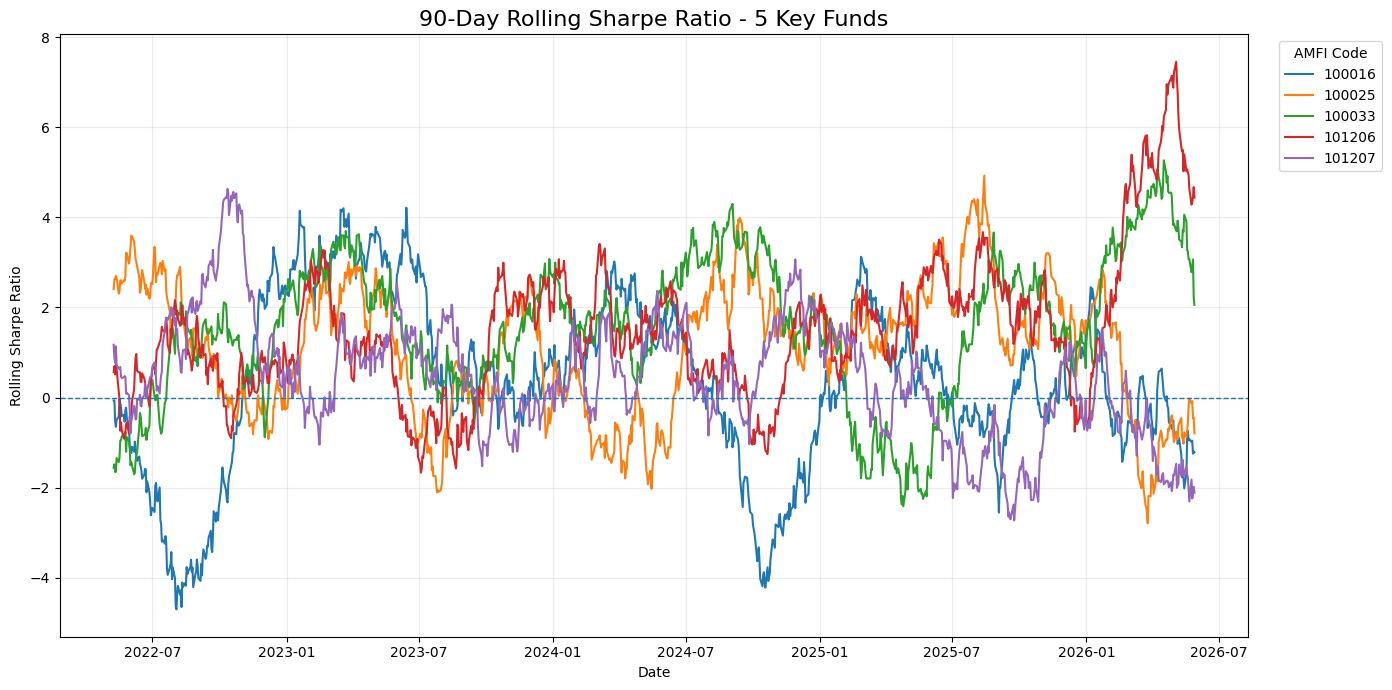

In [27]:
# ============================================================
# STEP 16.4 - ROLLING SHARPE CHART
# ============================================================

plt.figure(figsize=(14, 7))

for fund in key_funds:

    fund_data = returns_df[
        returns_df["amfi_code"] == fund
    ].copy()

    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe_90"],
        label=fund
    )

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "90-Day Rolling Sharpe Ratio - 5 Key Funds",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")

plt.legend(
    title="AMFI Code",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

print("Chart generated.")

In [28]:
# ============================================================
# STEP 16.5 - SAVE ROLLING SHARPE CHART
# ============================================================

chart_file = (
    REPORTS_DIR /
    r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\bluestock_mf_capstone\charts\rolling_sharpe_chart.png"
)

plt.savefig(
    chart_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved successfully:")
print(chart_file)

<Figure size 640x480 with 0 Axes>

Saved successfully:
C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\bluestock_mf_capstone\charts\rolling_sharpe_chart.png


In [29]:
# ============================================================
# STEP 16 - ROLLING 90-DAY SHARPE RATIO
# ============================================================

# Make sure returns are sorted correctly
returns_df = returns_df.sort_values(
    ["amfi_code", "date"]
).copy()

# 90-day rolling mean
returns_df["rolling_mean_90"] = (
    returns_df
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: x.rolling(
            window=90,
            min_periods=90
        ).mean()
    )
)

# 90-day rolling standard deviation
returns_df["rolling_std_90"] = (
    returns_df
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: x.rolling(
            window=90,
            min_periods=90
        ).std()
    )
)

# Annualized rolling Sharpe
returns_df["rolling_sharpe_90"] = (
    returns_df["rolling_mean_90"]
    / returns_df["rolling_std_90"]
    * np.sqrt(252)
)

print("Rolling 90-day Sharpe calculated.")

display(
    returns_df[
        [
            "amfi_code",
            "date",
            "rolling_mean_90",
            "rolling_std_90",
            "rolling_sharpe_90"
        ]
    ].tail(10)
)

Rolling 90-day Sharpe calculated.


,amfi_code,date,rolling_mean_90,rolling_std_90,rolling_sharpe_90
45990,149324,2026-05-18,0.001990,0.015725,2.008546
45991,149324,2026-05-19,0.001764,0.015637,1.790543
45992,149324,2026-05-20,0.002005,0.015414,2.064489
45993,149324,2026-05-21,0.002077,0.015415,2.138907
45994,149324,2026-05-22,0.001584,0.015569,1.615362
45995,149324,2026-05-25,0.001979,0.015377,2.042795
45996,149324,2026-05-26,0.001999,0.015368,2.064950
45997,149324,2026-05-27,0.001895,0.015407,1.952646
45998,149324,2026-05-28,0.001385,0.015632,1.406239
45999,149324,2026-05-29,0.001242,0.015616,1.262776


In [30]:
# ============================================================
# STEP 16.2 - VALIDATE ROLLING SHARPE
# ============================================================

print("=" * 60)
print("ROLLING SHARPE VALIDATION")
print("=" * 60)

print(
    "Total schemes:",
    returns_df["amfi_code"].nunique()
)

print(
    "Rolling Sharpe observations:",
    returns_df["rolling_sharpe_90"].notna().sum()
)

print(
    "Missing rolling Sharpe:",
    returns_df["rolling_sharpe_90"].isna().sum()
)

print("\nRolling Sharpe statistics:")

display(
    returns_df["rolling_sharpe_90"].describe()
)

ROLLING SHARPE VALIDATION
Total schemes: 40
Rolling Sharpe observations: 42400
Missing rolling Sharpe: 3560

Rolling Sharpe statistics:


count    42400.000000
mean         1.973971
std          3.486543
min         -4.771400
25%          0.067729
50%          1.275035
75%          2.551025
max         18.299609
Name: rolling_sharpe_90, dtype: float64

In [31]:
# ============================================================
# STEP 16.3 - SELECT 5 KEY FUNDS
# ============================================================

fund_observation_counts = (
    returns_df
    .groupby("amfi_code")
    .size()
    .sort_values(ascending=False)
)

key_funds = (
    fund_observation_counts
    .head(5)
    .index
    .tolist()
)

print("Selected 5 key funds:")

for i, fund in enumerate(key_funds, start=1):
    print(
        f"{i}. {fund} "
        f"({fund_observation_counts[fund]} observations)"
    )

Selected 5 key funds:
1. 100016 (1149 observations)
2. 100025 (1149 observations)
3. 100033 (1149 observations)
4. 101206 (1149 observations)
5. 101207 (1149 observations)


Chart generated.


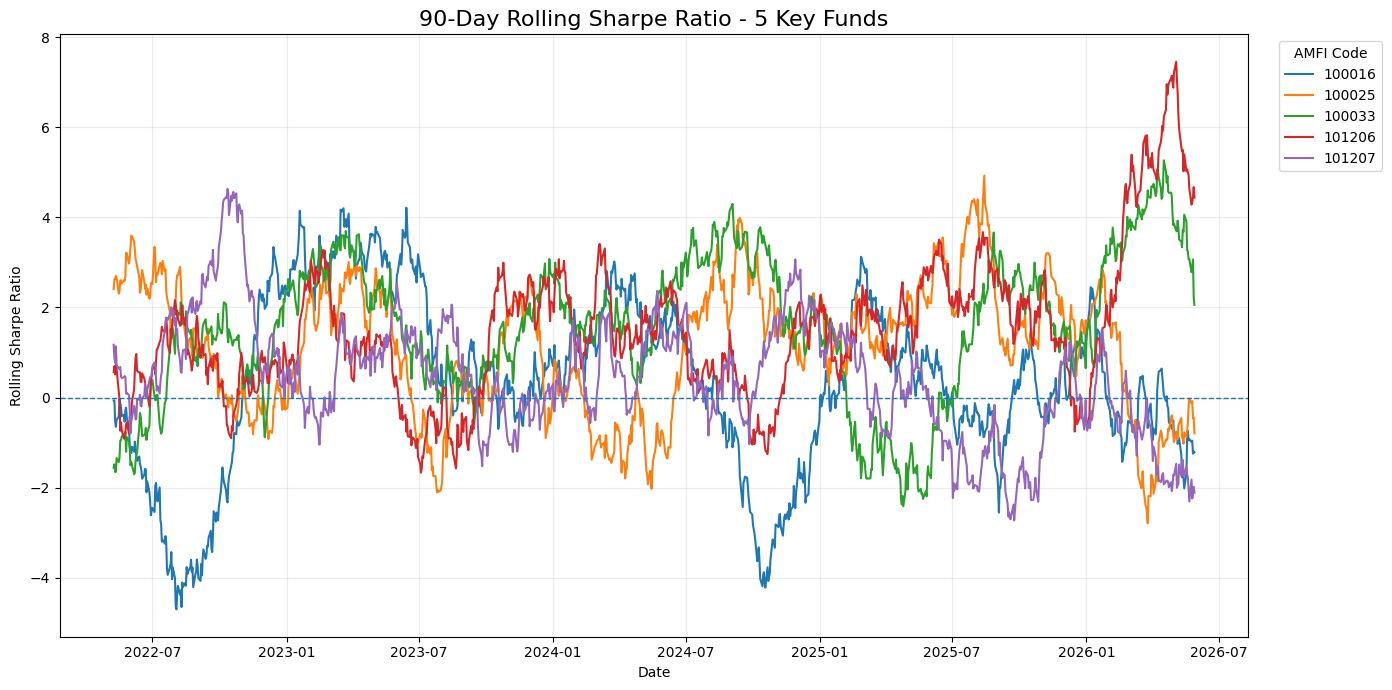

In [32]:
# ============================================================
# STEP 16.4 - ROLLING SHARPE CHART
# ============================================================

plt.figure(figsize=(14, 7))

for fund in key_funds:

    fund_data = returns_df[
        returns_df["amfi_code"] == fund
    ].copy()

    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe_90"],
        label=fund
    )

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "90-Day Rolling Sharpe Ratio - 5 Key Funds",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")

plt.legend(
    title="AMFI Code",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

print("Chart generated.")

In [33]:
# ============================================================
# STEP 17.1 - FIND TRANSACTION DATASET
# ============================================================

transaction_files = [
    file for file in csv_files
    if any(
        keyword in file.name.lower()
        for keyword in [
            "transaction",
            "investor",
            "sip"
        ]
    )
]

print("=" * 60)
print("TRANSACTION-RELATED CSV FILES")
print("=" * 60)

for i, file in enumerate(transaction_files, start=1):
    print(f"{i}. {file.relative_to(BASE_DIR)}")

TRANSACTION-RELATED CSV FILES
1. data\processed\04_monthly_sip_inflows.csv
2. data\processed\08_investor_transactions.csv
3. data\processed\investor_transactions.csv
4. data\raw\04_monthly_sip_inflows.csv
5. data\raw\08_investor_transactions.csv


In [34]:
# ============================================================
# STEP 17.2 - LOAD TRANSACTION DATA
# ============================================================

TRANSACTION_FILE = transaction_files[0]

print("Loading:")
print(TRANSACTION_FILE)

transactions = pd.read_csv(
    TRANSACTION_FILE
)

print("\nShape:")
print(transactions.shape)

print("\nColumns:")
print(transactions.columns.tolist())

print("\nFirst 5 rows:")
display(transactions.head())

Loading:
c:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\bluestock_mf_capstone\data\processed\04_monthly_sip_inflows.csv

Shape:
(48, 6)

Columns:
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

First 5 rows:


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,0.0
1,2022-02,11438,4.93,8.20,4.85,0.0
2,2022-03,12328,5.09,10.50,5.01,0.0
3,2022-04,11863,5.48,9.52,5.12,0.0
4,2022-05,12286,5.55,8.10,5.15,0.0


In [35]:
# ============================================================
# STEP 17.3 - INSPECT TRANSACTION COLUMNS
# ============================================================

print("=" * 60)
print("TRANSACTION DATA INFORMATION")
print("=" * 60)

for i, col in enumerate(transactions.columns):
    print(f"{i}: {repr(col)}")

print("\nData types:")
print(transactions.dtypes)

print("\nMissing values:")
print(transactions.isna().sum())

print("\nSample:")
display(transactions.head(10))

TRANSACTION DATA INFORMATION
0: 'month'
1: 'sip_inflow_crore'
2: 'active_sip_accounts_crore'
3: 'new_sip_accounts_lakh'
4: 'sip_aum_lakh_crore'
5: 'yoy_growth_pct'

Data types:
month                         object
sip_inflow_crore               int64
active_sip_accounts_crore    float64
new_sip_accounts_lakh        float64
sip_aum_lakh_crore           float64
yoy_growth_pct               float64
dtype: object

Missing values:
month                        0
sip_inflow_crore             0
active_sip_accounts_crore    0
new_sip_accounts_lakh        0
sip_aum_lakh_crore           0
yoy_growth_pct               0
dtype: int64

Sample:


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,0.0
1,2022-02,11438,4.93,8.20,4.85,0.0
2,2022-03,12328,5.09,10.50,5.01,0.0
3,2022-04,11863,5.48,9.52,5.12,0.0
4,2022-05,12286,5.55,8.10,5.15,0.0
5,2022-06,12276,5.60,7.50,5.18,0.0
6,2022-07,12140,5.65,9.21,5.25,0.0
7,2022-08,12694,5.71,8.90,5.31,0.0
8,2022-09,12976,5.80,9.40,5.41,0.0
9,2022-10,13040,5.93,9.52,5.55,0.0


In [36]:
# ============================================================
# STEP 17.4 - MAP TRANSACTION COLUMNS
# ============================================================

INVESTOR_COL = "YOUR_INVESTOR_COLUMN"
DATE_COL = "YOUR_DATE_COLUMN"
AMOUNT_COL = "YOUR_AMOUNT_COLUMN"
FUND_COL = "YOUR_FUND_COLUMN"
TYPE_COL = "YOUR_TRANSACTION_TYPE_COLUMN"

transactions = transactions.copy()

transactions[DATE_COL] = pd.to_datetime(
    transactions[DATE_COL],
    errors="coerce"
)

transactions[AMOUNT_COL] = pd.to_numeric(
    transactions[AMOUNT_COL],
    errors="coerce"
)

transactions = transactions.dropna(
    subset=[
        INVESTOR_COL,
        DATE_COL,
        AMOUNT_COL
    ]
).copy()

print("Clean transaction records:", len(transactions))
print(
    "Unique investors:",
    transactions[INVESTOR_COL].nunique()
)

KeyError: 'YOUR_DATE_COLUMN'

In [38]:
# ============================================================
# FIND ALL DATA FILES
# ============================================================

print("=" * 70)
print("ALL DATA FILES IN PROJECT")
print("=" * 70)

for file in sorted(DATA_DIR.rglob("*")):
    if file.is_file():
        print(file.relative_to(BASE_DIR))

ALL DATA FILES IN PROJECT
data\processed\01_fund_master.csv
data\processed\02_nav_history.csv
data\processed\03_aum_by_fund_house.csv
data\processed\04_monthly_sip_inflows.csv
data\processed\05_category_inflows.csv
data\processed\06_industry_folio_count.csv
data\processed\07_scheme_performance.csv
data\processed\08_investor_transactions.csv
data\processed\09_portfolio_holdings.csv
data\processed\10_benchmark_indices.csv
data\processed\Aditya Birla Sun Life Banking & PSU Debt Fund  - DIRECT - IDCW.csv
data\processed\Aditya Birla Sun Life Mutual Fund.csv
data\processed\alpha_beta.csv
data\processed\Axis ELSS Tax Saver Fund - Direct Plan - Growth Option.csv
data\processed\Axis Mutual Fund.csv
data\processed\Axis_Bluechip.csv
data\processed\cagr_comparison.csv
data\processed\data_quality_summary.txt
data\processed\fund_master.csv
data\processed\fund_master_clean.csv
data\processed\fund_scorecard.csv
data\processed\HDFC Money Market Fund - Growth Option - Direct Plan.csv
data\processed\HDFC

In [39]:
# ============================================================
# STEP 17.4 - LOAD INVESTOR TRANSACTIONS
# ============================================================

TRANSACTION_FILE = (
    PROCESSED_DIR / "08_investor_transactions.csv"
)

print("Loading:")
print(TRANSACTION_FILE)

transactions = pd.read_csv(
    TRANSACTION_FILE
)

print("\nShape:")
print(transactions.shape)

print("\nColumns:")
print(transactions.columns.tolist())

print("\nFirst 5 rows:")
display(transactions.head())



Loading:
c:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\bluestock_mf_capstone\data\processed\08_investor_transactions.csv

Shape:
(32778, 13)

Columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

First 5 rows:


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [40]:
# ============================================================
# STEP 17.5 - INSPECT INVESTOR TRANSACTION COLUMNS
# ============================================================

print("=" * 60)
print("INVESTOR TRANSACTION DATA")
print("=" * 60)

for i, col in enumerate(transactions.columns):
    print(f"{i}: {repr(col)}")

print("\nData types:")
print(transactions.dtypes)

print("\nMissing values:")
print(transactions.isna().sum())

print("\nFirst 10 rows:")
display(transactions.head(10))

INVESTOR TRANSACTION DATA
0: 'investor_id'
1: 'transaction_date'
2: 'amfi_code'
3: 'transaction_type'
4: 'amount_inr'
5: 'state'
6: 'city'
7: 'city_tier'
8: 'age_group'
9: 'gender'
10: 'annual_income_lakh'
11: 'payment_mode'
12: 'kyc_status'

Data types:
investor_id            object
transaction_date       object
amfi_code               int64
transaction_type       object
amount_inr              int64
state                  object
city                   object
city_tier              object
age_group              object
gender                 object
annual_income_lakh    float64
payment_mode           object
kyc_status             object
dtype: object

Missing values:
investor_id           0
transaction_date      0
amfi_code             0
transaction_type      0
amount_inr            0
state                 0
city                  0
city_tier             0
age_group             0
gender                0
annual_income_lakh    0
payment_mode          0
kyc_status            0
dtype: int64

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified
7,INV000616,2024-01-01,100016,SIP,933,Maharashtra,Nashik,B30,36-45,Male,50.4,Mandate,Verified
8,INV003670,2024-01-01,119120,SIP,10672,Punjab,Chandigarh,T30,36-45,Male,38.4,Net Banking,Verified
9,INV002054,2024-01-01,148567,SIP,1111,Telangana,Hyderabad,T30,26-35,Male,17.8,Net Banking,Verified


In [46]:
# ============================================================
# STEP 17.6 - MAP ACTUAL TRANSACTION COLUMNS
# ============================================================

INVESTOR_COL = "investor_id"
DATE_COL = "transaction_date"
FUND_COL = "amfi_code"
TYPE_COL = "transaction_type"
AMOUNT_COL = "amount_inr"

print("=" * 60)
print("TRANSACTION COLUMN MAPPING")
print("=" * 60)

print("Investor :", INVESTOR_COL)
print("Date     :", DATE_COL)
print("Fund     :", FUND_COL)
print("Type     :", TYPE_COL)
print("Amount   :", AMOUNT_COL)

# Verify columns exist
required_columns = [
    INVESTOR_COL,
    DATE_COL,
    FUND_COL,
    TYPE_COL,
    AMOUNT_COL
]

missing = [
    col for col in required_columns
    if col not in transactions.columns
]

if missing:
    raise ValueError(
        f"Missing columns: {missing}"
    )

print("\nAll required columns found successfully.")

TRANSACTION COLUMN MAPPING
Investor : investor_id
Date     : transaction_date
Fund     : amfi_code
Type     : transaction_type
Amount   : amount_inr

All required columns found successfully.


In [47]:
# ============================================================
# STEP 17.7 - CLEAN TRANSACTION DATA
# ============================================================

transactions = transactions.copy()

# Convert date
transactions[DATE_COL] = pd.to_datetime(
    transactions[DATE_COL],
    errors="coerce"
)

# Convert amount
transactions[AMOUNT_COL] = pd.to_numeric(
    transactions[AMOUNT_COL],
    errors="coerce"
)

# Clean text fields
transactions[INVESTOR_COL] = (
    transactions[INVESTOR_COL]
    .astype(str)
    .str.strip()
)

transactions[FUND_COL] = (
    transactions[FUND_COL]
    .astype(str)
    .str.strip()
)

transactions[TYPE_COL] = (
    transactions[TYPE_COL]
    .astype(str)
    .str.strip()
)

# Remove invalid records
transactions = transactions.dropna(
    subset=[
        INVESTOR_COL,
        DATE_COL,
        AMOUNT_COL
    ]
).copy()

# Keep positive investment amounts
transactions = transactions[
    transactions[AMOUNT_COL] > 0
].copy()

# Sort
transactions = transactions.sort_values(
    [INVESTOR_COL, DATE_COL]
).reset_index(drop=True)

print("=" * 60)
print("CLEAN TRANSACTION DATA")
print("=" * 60)

print("Rows:", len(transactions))

print(
    "Unique investors:",
    transactions[INVESTOR_COL].nunique()
)

print(
    "Date range:",
    transactions[DATE_COL].min(),
    "to",
    transactions[DATE_COL].max()
)

display(transactions.head())

CLEAN TRANSACTION DATA
Rows: 32778
Unique investors: 5000
Date range: 2024-01-01 00:00:00 to 2025-05-30 00:00:00


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified
1,INV000001,2025-01-14,148569,LUMPSUM,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified
2,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending
3,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified
4,INV000002,2024-07-14,149323,LUMPSUM,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified


In [48]:
# ============================================================
# STEP 17.8 - TRANSACTION TYPE CHECK
# ============================================================

print("=" * 60)
print("TRANSACTION TYPES")
print("=" * 60)

transaction_types = (
    transactions[TYPE_COL]
    .value_counts(dropna=False)
)

display(transaction_types)

TRANSACTION TYPES


transaction_type
SIP           19716
LUMPSUM        8095
REDEMPTION     4967
Name: count, dtype: int64

In [49]:
# ============================================================
# STEP 17.9 - FILTER SIP TRANSACTIONS
# ============================================================

sip_mask = (
    transactions[TYPE_COL]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.contains("sip", na=False)
)

sip_transactions = transactions[
    sip_mask
].copy()

print("=" * 60)
print("SIP TRANSACTIONS")
print("=" * 60)

print(
    "Total SIP transactions:",
    len(sip_transactions)
)

print(
    "Unique SIP investors:",
    sip_transactions[INVESTOR_COL].nunique()
)

display(sip_transactions.head())

SIP TRANSACTIONS
Total SIP transactions: 19716
Unique SIP investors: 4762


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified
2,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending
3,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified
5,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified
8,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified


In [50]:
# ============================================================
# STEP 17.10 - INVESTOR COHORT YEAR
# ============================================================

first_transaction = (
    transactions
    .groupby(INVESTOR_COL)[DATE_COL]
    .min()
    .reset_index(
        name="first_transaction_date"
    )
)

first_transaction["cohort_year"] = (
    first_transaction[
        "first_transaction_date"
    ].dt.year
)

print("=" * 60)
print("INVESTOR COHORTS")
print("=" * 60)

display(first_transaction.head(10))

print(
    "\nNumber of cohorts:",
    first_transaction["cohort_year"].nunique()
)# ============================================================
# STEP 17.10 - INVESTOR COHORT YEAR
# ============================================================

first_transaction = (
    transactions
    .groupby(INVESTOR_COL)[DATE_COL]
    .min()
    .reset_index(
        name="first_transaction_date"
    )
)

first_transaction["cohort_year"] = (
    first_transaction[
        "first_transaction_date"
    ].dt.year
)

print("=" * 60)
print("INVESTOR COHORTS")
print("=" * 60)

display(first_transaction.head(10))

print(
    "\nNumber of cohorts:",
    first_transaction["cohort_year"].nunique()
)

INVESTOR COHORTS


,investor_id,first_transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024
5,INV000006,2024-01-02,2024
6,INV000007,2024-01-03,2024
7,INV000008,2024-05-27,2024
8,INV000009,2024-01-10,2024
9,INV000010,2024-04-11,2024



Number of cohorts: 2
INVESTOR COHORTS


,investor_id,first_transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024
5,INV000006,2024-01-02,2024
6,INV000007,2024-01-03,2024
7,INV000008,2024-05-27,2024
8,INV000009,2024-01-10,2024
9,INV000010,2024-04-11,2024



Number of cohorts: 2


In [51]:
# ============================================================
# STEP 17.11 - ASSIGN COHORT YEAR
# ============================================================

transactions = transactions.merge(
    first_transaction[
        [
            INVESTOR_COL,
            "first_transaction_date",
            "cohort_year"
        ]
    ],
    on=INVESTOR_COL,
    how="left"
)

print("Cohort year assigned successfully.")

display(
    transactions[
        [
            INVESTOR_COL,
            DATE_COL,
            "cohort_year"
        ]
    ].head(10)
)

Cohort year assigned successfully.


,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000001,2025-01-14,2024
2,INV000001,2025-01-19,2024
3,INV000002,2024-03-29,2024
4,INV000002,2024-07-14,2024
5,INV000002,2024-09-21,2024
6,INV000002,2024-10-03,2024
7,INV000002,2025-01-23,2024
8,INV000002,2025-05-17,2024
9,INV000003,2024-07-16,2024


In [52]:
# ============================================================
# STEP 17.12 - TOTAL INVESTED BY COHORT
# ============================================================

cohort_total_invested = (
    transactions
    .groupby("cohort_year")
    .agg(
        total_invested_inr=(
            AMOUNT_COL,
            "sum"
        ),
        unique_investors=(
            INVESTOR_COL,
            "nunique"
        ),
        transaction_count=(
            INVESTOR_COL,
            "count"
        )
    )
    .reset_index()
)

display(cohort_total_invested)

,cohort_year,total_invested_inr,unique_investors,transaction_count
0,2024,3491125187,4803,32499
1,2025,30455243,197,279


In [53]:
# ============================================================
# STEP 17.13 - AVERAGE SIP AMOUNT BY COHORT
# ============================================================

sip_transactions = sip_transactions.merge(
    first_transaction[
        [
            INVESTOR_COL,
            "cohort_year"
        ]
    ],
    on=INVESTOR_COL,
    how="left"
)

cohort_avg_sip = (
    sip_transactions
    .groupby("cohort_year")
    .agg(
        avg_sip_amount_inr=(
            AMOUNT_COL,
            "mean"
        ),
        sip_transaction_count=(
            INVESTOR_COL,
            "count"
        ),
        sip_investor_count=(
            INVESTOR_COL,
            "nunique"
        )
    )
    .reset_index()
)

display(cohort_avg_sip)


,cohort_year,avg_sip_amount_inr,sip_transaction_count,sip_investor_count
0,2024,10996.885825,19549,4624
1,2025,13505.209581,167,138


In [54]:
# ============================================================
# STEP 17.14 - TOP FUND PREFERENCE BY COHORT
# ============================================================

fund_preference = (
    sip_transactions
    .groupby(
        [
            "cohort_year",
            FUND_COL
        ]
    )
    .size()
    .reset_index(
        name="sip_transaction_count"
    )
)

fund_preference["rank"] = (
    fund_preference
    .groupby("cohort_year")[
        "sip_transaction_count"
    ]
    .rank(
        method="first",
        ascending=False
    )
)

top_fund_by_cohort = (
    fund_preference[
        fund_preference["rank"] == 1
    ]
    .drop(columns="rank")
    .reset_index(drop=True)
)

print("=" * 60)
print("TOP FUND BY COHORT")
print("=" * 60)

display(top_fund_by_cohort)

TOP FUND BY COHORT


,cohort_year,amfi_code,sip_transaction_count
0,2024,120504,536
1,2025,119599,8


In [55]:
# ============================================================
# STEP 17.15 - FINAL COHORT ANALYSIS
# ============================================================

cohort_analysis = (
    cohort_total_invested
    .merge(
        cohort_avg_sip,
        on="cohort_year",
        how="left"
    )
    .merge(
        top_fund_by_cohort[
            [
                "cohort_year",
                FUND_COL,
                "sip_transaction_count"
            ]
        ],
        on="cohort_year",
        how="left"
    )
)

cohort_analysis = cohort_analysis.sort_values(
    "cohort_year"
).reset_index(drop=True)

print("=" * 70)
print("FINAL INVESTOR COHORT ANALYSIS")
print("=" * 70)

display(cohort_analysis)

FINAL INVESTOR COHORT ANALYSIS


,cohort_year,total_invested_inr,unique_investors,transaction_count,avg_sip_amount_inr,sip_transaction_count_x,sip_investor_count,amfi_code,sip_transaction_count_y
0,2024,3491125187,4803,32499,10996.885825,19549,4624,120504,536
1,2025,30455243,197,279,13505.209581,167,138,119599,8


In [56]:
# ============================================================
# STEP 17.16 - SAVE COHORT ANALYSIS
# ============================================================

cohort_file = (
    PROCESSED_DIR /
    "investor_cohort_analysis.csv"
)

cohort_analysis.to_csv(
    cohort_file,
    index=False
)

print("Saved successfully:")
print(cohort_file)

print("\nRows saved:", len(cohort_analysis))

Saved successfully:
c:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\bluestock_mf_capstone\data\processed\investor_cohort_analysis.csv

Rows saved: 2


In [57]:
# ============================================================
# STEP 18.1 - SORT SIP TRANSACTIONS
# ============================================================

sip_transactions = sip_transactions.sort_values(
    [INVESTOR_COL, DATE_COL]
).reset_index(drop=True)

print("SIP transactions sorted successfully.")

display(
    sip_transactions[
        [
            INVESTOR_COL,
            DATE_COL,
            AMOUNT_COL,
            FUND_COL
        ]
    ].head(10)
)

SIP transactions sorted successfully.


,investor_id,transaction_date,amount_inr,amfi_code
0,INV000001,2024-11-04,44856,120505
1,INV000001,2025-01-19,3090,125497
2,INV000002,2024-03-29,2830,149322
3,INV000002,2024-09-21,2354,120841
4,INV000002,2025-05-17,2690,119094
5,INV000003,2024-07-16,2676,101207
6,INV000003,2025-03-11,15185,149322
7,INV000004,2024-03-16,960,101208
8,INV000004,2024-04-11,20602,119095
9,INV000004,2024-05-09,541,120844


In [58]:
# ============================================================
# STEP 18.2 - CALCULATE SIP DATE GAPS
# ============================================================

sip_transactions["sip_gap_days"] = (
    sip_transactions
    .groupby(INVESTOR_COL)[DATE_COL]
    .diff()
    .dt.days
)

display(
    sip_transactions[
        [
            INVESTOR_COL,
            DATE_COL,
            "sip_gap_days"
        ]
    ].head(15)
)

,investor_id,transaction_date,sip_gap_days
0,INV000001,2024-11-04,NaN
1,INV000001,2025-01-19,76.0
2,INV000002,2024-03-29,NaN
3,INV000002,2024-09-21,176.0
4,INV000002,2025-05-17,238.0
5,INV000003,2024-07-16,NaN
6,INV000003,2025-03-11,238.0
7,INV000004,2024-03-16,NaN
8,INV000004,2024-04-11,26.0
9,INV000004,2024-05-09,28.0


In [59]:
# ============================================================
# STEP 18.3 - SIP TRANSACTION COUNT
# ============================================================

investor_sip_summary = (
    sip_transactions
    .groupby(INVESTOR_COL)
    .agg(
        sip_transaction_count=(
            DATE_COL,
            "count"
        ),
        first_sip_date=(
            DATE_COL,
            "min"
        ),
        last_sip_date=(
            DATE_COL,
            "max"
        )
    )
    .reset_index()
)

display(
    investor_sip_summary.head(10)
)

,investor_id,sip_transaction_count,first_sip_date,last_sip_date
0,INV000001,2,2024-11-04,2025-01-19
1,INV000002,3,2024-03-29,2025-05-17
2,INV000003,2,2024-07-16,2025-03-11
3,INV000004,6,2024-03-16,2025-05-17
4,INV000005,3,2024-09-13,2024-10-11
5,INV000006,5,2024-01-02,2025-05-11
6,INV000007,5,2024-01-03,2025-02-24
7,INV000008,6,2024-05-27,2025-05-14
8,INV000009,4,2024-02-20,2024-11-02
9,INV000010,6,2024-04-11,2025-03-01


In [60]:
# ============================================================
# STEP 18.4 - FILTER 6+ SIP INVESTORS
# ============================================================

eligible_investors = investor_sip_summary[
    investor_sip_summary[
        "sip_transaction_count"
    ] >= 6
].copy()

print(
    "Investors with 6+ SIP transactions:",
    len(eligible_investors)
)

display(
    eligible_investors.head(10)
)

Investors with 6+ SIP transactions: 1362


,investor_id,sip_transaction_count,first_sip_date,last_sip_date
3,INV000004,6,2024-03-16,2025-05-17
7,INV000008,6,2024-05-27,2025-05-14
9,INV000010,6,2024-04-11,2025-03-01
10,INV000011,7,2024-01-03,2024-08-31
11,INV000012,8,2024-03-27,2025-04-30
12,INV000013,7,2024-04-18,2025-03-16
13,INV000014,7,2024-02-23,2025-05-20
22,INV000023,8,2024-03-21,2025-05-05
27,INV000028,6,2024-02-07,2025-05-20
28,INV000029,7,2024-05-16,2025-05-15


In [61]:
# ============================================================
# STEP 18.5 - AVERAGE SIP GAP
# ============================================================

avg_gap = (
    sip_transactions
    .groupby(INVESTOR_COL)["sip_gap_days"]
    .mean()
    .reset_index(
        name="avg_sip_gap_days"
    )
)

eligible_investors = eligible_investors.merge(
    avg_gap,
    on=INVESTOR_COL,
    how="left"
)

display(
    eligible_investors[
        [
            INVESTOR_COL,
            "sip_transaction_count",
            "avg_sip_gap_days"
        ]
    ].head(10)
)

,investor_id,sip_transaction_count,avg_sip_gap_days
0,INV000004,6,85.400000
1,INV000008,6,70.400000
2,INV000010,6,64.800000
3,INV000011,7,40.166667
4,INV000012,8,57.000000
5,INV000013,7,55.333333
6,INV000014,7,75.333333
7,INV000023,8,58.571429
8,INV000028,6,93.600000
9,INV000029,7,60.666667


In [62]:
# ============================================================
# STEP 18.6 - AT-RISK FLAG
# ============================================================

eligible_investors["continuity_status"] = np.where(
    eligible_investors["avg_sip_gap_days"] > 35,
    "AT-RISK",
    "ACTIVE"
)

display(
    eligible_investors[
        [
            INVESTOR_COL,
            "sip_transaction_count",
            "avg_sip_gap_days",
            "continuity_status"
        ]
    ].head(20)
)

,investor_id,sip_transaction_count,avg_sip_gap_days,continuity_status
0,INV000004,6,85.400000,AT-RISK
1,INV000008,6,70.400000,AT-RISK
2,INV000010,6,64.800000,AT-RISK
3,INV000011,7,40.166667,AT-RISK
4,INV000012,8,57.000000,AT-RISK
5,INV000013,7,55.333333,AT-RISK
6,INV000014,7,75.333333,AT-RISK
7,INV000023,8,58.571429,AT-RISK
8,INV000028,6,93.600000,AT-RISK
9,INV000029,7,60.666667,AT-RISK


In [63]:
# ============================================================
# STEP 18.7 - SIP CONTINUITY SUMMARY
# ============================================================

total_eligible = len(
    eligible_investors
)

at_risk_count = (
    eligible_investors[
        eligible_investors[
            "continuity_status"
        ] == "AT-RISK"
    ]
    .shape[0]
)

active_count = (
    eligible_investors[
        eligible_investors[
            "continuity_status"
        ] == "ACTIVE"
    ]
    .shape[0]
)

at_risk_rate = (
    at_risk_count / total_eligible * 100
    if total_eligible > 0
    else 0
)

continuity_rate = (
    active_count / total_eligible * 100
    if total_eligible > 0
    else 0
)

print("=" * 60)
print("SIP CONTINUITY SUMMARY")
print("=" * 60)

print("Eligible investors:", total_eligible)
print("Active:", active_count)
print("At-risk:", at_risk_count)

print(
    f"Continuity rate: {continuity_rate:.2f}%"
)

print(
    f"At-risk rate: {at_risk_rate:.2f}%"
)

SIP CONTINUITY SUMMARY
Eligible investors: 1362
Active: 30
At-risk: 1332
Continuity rate: 2.20%
At-risk rate: 97.80%


In [64]:
# ============================================================
# STEP 18.8 - HIGHEST SIP GAP INVESTORS
# ============================================================

highest_gap = (
    eligible_investors
    .sort_values(
        "avg_sip_gap_days",
        ascending=False
    )
    .head(20)
)

display(
    highest_gap[
        [
            INVESTOR_COL,
            "sip_transaction_count",
            "first_sip_date",
            "last_sip_date",
            "avg_sip_gap_days",
            "continuity_status"
        ]
    ]
)

,investor_id,sip_transaction_count,first_sip_date,last_sip_date,avg_sip_gap_days,continuity_status
506,INV001890,6,2024-01-02,2025-05-29,102.6,AT-RISK
323,INV001156,6,2024-01-02,2025-05-28,102.4,AT-RISK
1188,INV004296,6,2024-01-02,2025-05-27,102.2,AT-RISK
910,INV003325,6,2024-01-07,2025-05-26,101.0,AT-RISK
150,INV000522,6,2024-01-12,2025-05-30,100.8,AT-RISK
183,INV000608,6,2024-01-09,2025-05-24,100.2,AT-RISK
503,INV001883,6,2024-01-16,2025-05-26,99.2,AT-RISK
576,INV002166,6,2024-01-01,2025-05-11,99.2,AT-RISK
380,INV001367,6,2024-01-03,2025-05-12,99.0,AT-RISK
406,INV001491,6,2024-01-07,2025-05-15,98.8,AT-RISK


In [65]:
# ============================================================
# STEP 18.9 - SAVE SIP CONTINUITY REPORT
# ============================================================

continuity_file = (
    PROCESSED_DIR /
    "sip_continuity_analysis.csv"
)

eligible_investors.to_csv(
    continuity_file,
    index=False
)

print("Saved successfully:")
print(continuity_file)

print(
    "Rows saved:",
    len(eligible_investors)
)

Saved successfully:
c:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\bluestock_mf_capstone\data\processed\sip_continuity_analysis.csv
Rows saved: 1362


In [66]:
# ============================================================
# STEP 19.1 - LOAD FUND SCORECARD
# ============================================================

SCORECARD_FILE = (
    PROCESSED_DIR /
    "fund_scorecard.csv"
)

fund_scorecard = pd.read_csv(
    SCORECARD_FILE
)

print("=" * 60)
print("FUND SCORECARD")
print("=" * 60)

print("Shape:", fund_scorecard.shape)

print("\nColumns:")
print(fund_scorecard.columns.tolist())

print("\nFirst 5 rows:")
display(fund_scorecard.head())

FUND SCORECARD
Shape: (40, 27)

Columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'Sharpe_Rank', 'Sortino_Rank', 'Alpha_Rank', 'Beta_Rank', 'Drawdown_Rank', 'Return_Rank', 'Expense_Rank', 'Fund_Score']

First 5 rows:


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,morningstar_rating,risk_grade,Sharpe_Rank,Sortino_Rank,Alpha_Rank,Beta_Rank,Drawdown_Rank,Return_Rank,Expense_Rank,Fund_Score
0,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,4,Very High,14.0,9.0,20.0,22.0,11.0,2.0,5.0,100.000000
1,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,...,4,High,11.0,26.0,2.0,19.0,16.0,7.0,26.0,94.936709
2,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,...,5,Very High,17.0,17.0,4.0,16.0,14.0,3.0,23.0,94.620253
3,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,5,Moderately High,10.0,12.0,3.0,14.0,20.0,11.0,19.0,91.772152
4,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,5,Very High,13.0,23.0,18.0,9.0,32.0,1.0,18.0,80.379747


In [67]:
# ============================================================
# STEP 19.2 - CHECK RISK GRADES
# ============================================================

print("=" * 60)
print("RISK GRADES")
print("=" * 60)

print(
    fund_scorecard["risk_grade"]
    .value_counts(dropna=False)
)

RISK GRADES
risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64


In [68]:
# ============================================================
# STEP 19.3 - CHECK SHARPE COLUMN
# ============================================================

sharpe_candidates = [
    col for col in fund_scorecard.columns
    if "sharpe" in col.lower()
]

print("Sharpe-related columns:")
print(sharpe_candidates)# ============================================================
# STEP 19.3 - CHECK SHARPE COLUMN
# ============================================================

sharpe_candidates = [
    col for col in fund_scorecard.columns
    if "sharpe" in col.lower()
]

print("Sharpe-related columns:")
print(sharpe_candidates)

Sharpe-related columns:
['sharpe_ratio', 'Sharpe_Rank']
Sharpe-related columns:
['sharpe_ratio', 'Sharpe_Rank']


In [69]:
# ============================================================
# STEP 19.4 - RECOMMENDER FUNCTION
# ============================================================

def recommend_funds(
    risk_appetite,
    scorecard=fund_scorecard,
    top_n=3
):
    """
    Recommend top funds based on Sharpe Ratio
    within the selected risk grade.

    Accepted risk appetites:
        Low
        Moderate
        High
    """

    risk_appetite = (
        str(risk_appetite)
        .strip()
        .title()
    )

    valid_risks = [
        "Low",
        "Moderate",
        "High"
    ]

    if risk_appetite not in valid_risks:
        raise ValueError(
            f"Invalid risk appetite: {risk_appetite}. "
            f"Choose from {valid_risks}."
        )

    filtered = scorecard[
        scorecard["risk_grade"] == risk_appetite
    ].copy()

    if filtered.empty:
        print(
            f"No funds found for risk appetite: "
            f"{risk_appetite}"
        )
        return pd.DataFrame()

    filtered["sharpe_ratio"] = pd.to_numeric(
        filtered["sharpe_ratio"],
        errors="coerce"
    )

    recommendations = (
        filtered
        .dropna(subset=["sharpe_ratio"])
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(top_n)
        .copy()
    )

    recommendations.insert(
        0,
        "rank",
        range(1, len(recommendations) + 1)
    )

    recommendations[
        "recommendation"
    ] = "Recommended"

    return recommendations

In [70]:
# ============================================================
# STEP 19.5 - LOW RISK RECOMMENDATION
# ============================================================

low_recommendations = recommend_funds(
    "Low"
)

display(low_recommendations)

,rank,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,...,risk_grade,Sharpe_Rank,Sortino_Rank,Alpha_Rank,Beta_Rank,Drawdown_Rank,Return_Rank,Expense_Rank,Fund_Score,recommendation
10,1,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,...,Low,1.0,1.0,3.0,2.0,37.0,35.0,6.0,62.025316,Recommended
21,2,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,...,Low,2.0,2.0,12.0,6.0,35.0,37.0,3.0,49.367089,Recommended
32,3,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Regular,6.18,5.14,7.95,3.96,...,Low,3.0,3.0,19.0,4.0,36.0,40.0,10.0,25.949367,Recommended


In [71]:
# ============================================================
# STEP 19.6 - MODERATE RISK RECOMMENDATION
# ============================================================

moderate_recommendations = recommend_funds(
    "Moderate"
)

display(moderate_recommendations)

,rank,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,...,risk_grade,Sharpe_Rank,Sortino_Rank,Alpha_Rank,Beta_Rank,Drawdown_Rank,Return_Rank,Expense_Rank,Fund_Score,recommendation
5,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,...,Moderate,7.0,10.0,10.0,15.0,25.0,17.0,20.0,72.151899,Recommended
23,2,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,...,Moderate,7.0,7.0,31.0,16.0,23.0,16.0,25.0,43.987342,Recommended
11,3,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,...,Moderate,8.0,26.0,27.0,21.0,9.0,20.0,11.0,62.025316,Recommended


In [72]:
# ============================================================
# STEP 19.7 - HIGH RISK RECOMMENDATION
# ============================================================

high_recommendations = recommend_funds(
    "High"
)

display(high_recommendations)

,rank,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,...,risk_grade,Sharpe_Rank,Sortino_Rank,Alpha_Rank,Beta_Rank,Drawdown_Rank,Return_Rank,Expense_Rank,Fund_Score,recommendation
1,1,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,...,High,11.0,26.0,2.0,19.0,16.0,7.0,26.0,94.936709,Recommended
6,2,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,...,High,12.0,18.0,26.0,19.0,18.0,8.0,14.0,71.202532,Recommended
14,3,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,Regular,14.12,17.16,19.00,16.14,...,High,17.0,15.0,22.0,17.0,7.0,9.0,30.0,58.227848,Recommended


In [73]:
# ============================================================
# STEP 19.8 - TEST ALL RISK PROFILES
# ============================================================

for risk in ["Low", "Moderate", "High"]:

    print("\n" + "=" * 60)
    print(f"{risk.upper()} RISK RECOMMENDATIONS")
    print("=" * 60)

    result = recommend_funds(risk)

    display(
        result[
            [
                "rank",
                "amfi_code",
                "risk_grade",
                "sharpe_ratio",
                "recommendation"
            ]
        ]
    )


LOW RISK RECOMMENDATIONS


,rank,amfi_code,risk_grade,sharpe_ratio,recommendation
10,1,120507,Low,7.68,Recommended
21,2,120844,Low,6.18,Recommended
32,3,101208,Low,5.14,Recommended



MODERATE RISK RECOMMENDATIONS


,rank,amfi_code,risk_grade,sharpe_ratio,recommendation
5,1,148567,Moderate,1.06,Recommended
23,2,100016,Moderate,1.06,Recommended
11,3,120504,Moderate,1.03,Recommended



HIGH RISK RECOMMENDATIONS


,rank,amfi_code,risk_grade,sharpe_ratio,recommendation
1,1,120842,High,0.96,Recommended
6,2,120505,High,0.95,Recommended
14,3,149323,High,0.90,Recommended
